In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("retail_sales_dataset (1).csv")

df.head()


,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


In [ ]:
print("Shape of the dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of the dataset:
(4310, 21)

Column names:
['order_id', 'order_date', 'customer_id', 'customer_name', 'age', 'gender', 'region', 'city', 'product_category', 'product_name', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit', 'shipping_cost', 'payment_method', 'customer_satisfaction', 'return_flag', 'order_status', 'days_to_ship']

Data types:
order_id                  object
order_date                object
customer_id               object
customer_name             object
age                      float64
gender                    object
region                    object
city                      object
product_category          object
product_name              object
quantity                 float64
unit_price               float64
discount_pct             float64
sales_amount             float64
profit                   float64
shipping_cost            float64
payment_method            object
customer_satisfaction    float64
return_flag               object
order_s

In [ ]:
print("Descriptive Statistics:")
print(df.describe())

print("\nMean:")
print(df.select_dtypes(include='number').mean())

print("\nMedian:")
print(df.select_dtypes(include='number').median())

print("\nMode:")
print(df.select_dtypes(include='number').mode().iloc[0])

print("\nStandard Deviation:")
print(df.select_dtypes(include='number').std())

Descriptive Statistics:
               age     quantity    unit_price  discount_pct  sales_amount  \
count  4150.000000  4170.000000   4280.000000   4143.000000  4.280000e+03   
mean     35.335181     7.379856  10621.154428      0.202085  6.235864e+04   
std      35.709382    43.578352  17323.704016      0.118095  3.166998e+05   
min      -7.000000    -1.000000     50.260000      0.000000  3.945000e+01   
25%      26.000000     3.000000    672.222500      0.100000  2.462165e+03   
50%      34.000000     5.000000   2228.435000      0.210000  9.548075e+03   
75%      42.000000     8.000000  12717.435000      0.310000  5.006964e+04   
max     999.000000   999.000000  79957.920000      0.400000  1.736031e+07   

             profit  shipping_cost  customer_satisfaction  days_to_ship  
count  4.280000e+03    4280.000000            3932.000000   4180.000000  
mean   1.168713e+04      63.358836               3.016531      5.620335  
std    5.287522e+04      18.312281               1.413127   

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

print(df['order_date'].dtype)
print(df['order_date'].min())
print(df['order_date'].max())

datetime64[ns]
2020-01-01 00:00:00
2024-12-30 00:00:00


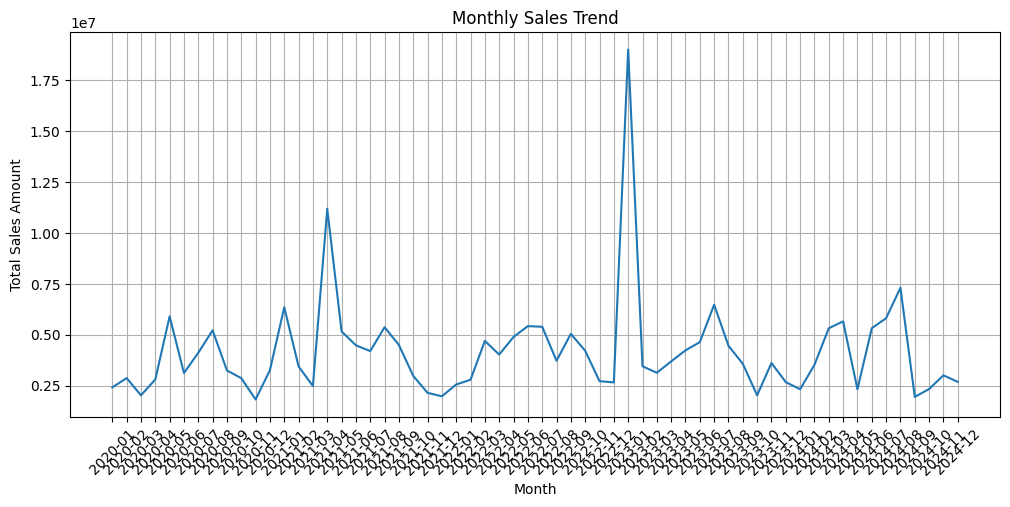

In [ ]:
monthly_sales = df.groupby(
    df['order_date'].dt.to_period('M')
)['sales_amount'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Observation:
The monthly sales trend shows considerable variation in sales over the period from 2020 to 2024. Sales fluctuate from month to month, with a few months showing unusually high sales compared with the typical monthly level. This indicates that sales performance is not consistent throughout the period and may be influenced by specific high-value transactions or seasonal factors.

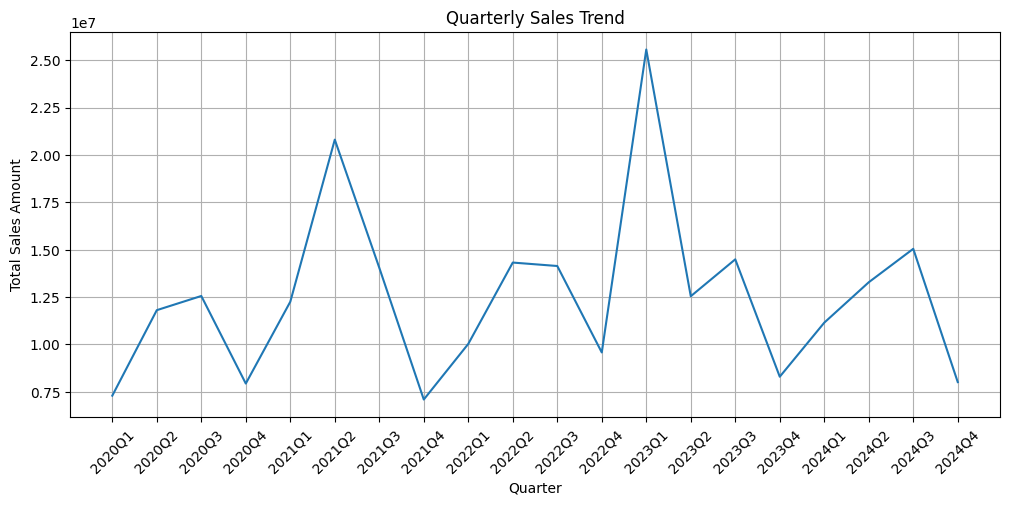

In [ ]:
quarterly_sales = df.groupby(
    df['order_date'].dt.to_period('Q')
)['sales_amount'].sum()

plt.figure(figsize=(12, 5))
plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Observation:**
The quarterly sales trend shows significant fluctuations between quarters from 2020 to 2024. Sales reach notable peaks in 2021 Q2 and 2023 Q1, while some quarters show relatively lower sales. The variation suggests that sales performance changes considerably across different periods.

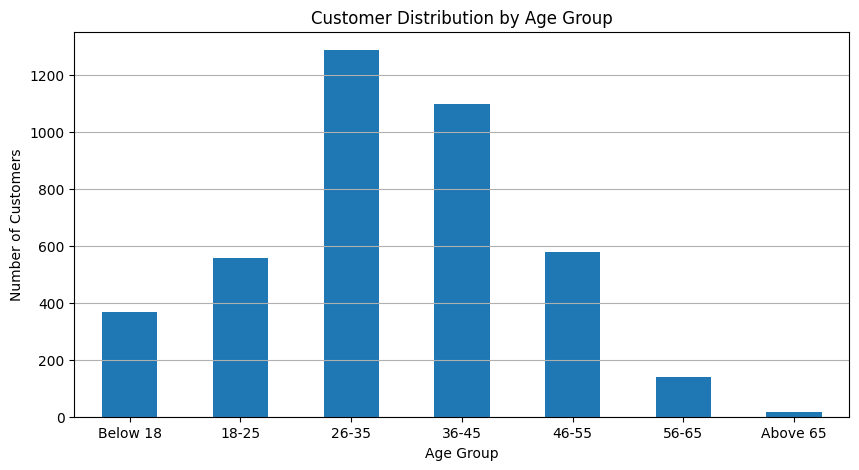

In [ ]:
age_group_customers = df.groupby(
    'age_group',
    observed=False
)['customer_id'].nunique()

plt.figure(figsize=(10, 5))
age_group_customers.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

**Observation**:
The 26–35 age group has the highest number of customers, followed by the 36–45 age group. The 56–65 and Above 65 groups have comparatively fewer customers. This indicates that customers between 26 and 45 years form the largest portion of the customer base.

In [ ]:
print("Gender Breakdown:")
print(df['gender'].value_counts(dropna=False))

Gender Breakdown:
gender
Other     1442
Male      1207
Female    1191
male        68
MALE        62
f           57
m           55
F           54
M           50
FEMALE      49
female      45
NaN         30
Name: count, dtype: int64


In [ ]:
df['gender_clean'] = df['gender'].str.strip().str.lower()

df['gender_clean'] = df['gender_clean'].replace({
    'm': 'Male',
    'male': 'Male',
    'f': 'Female',
    'female': 'Female',
    'other': 'Other'
})

print(df['gender_clean'].value_counts(dropna=False))

gender_clean
Other     1442
Male      1442
Female    1396
NaN         30
Name: count, dtype: int64


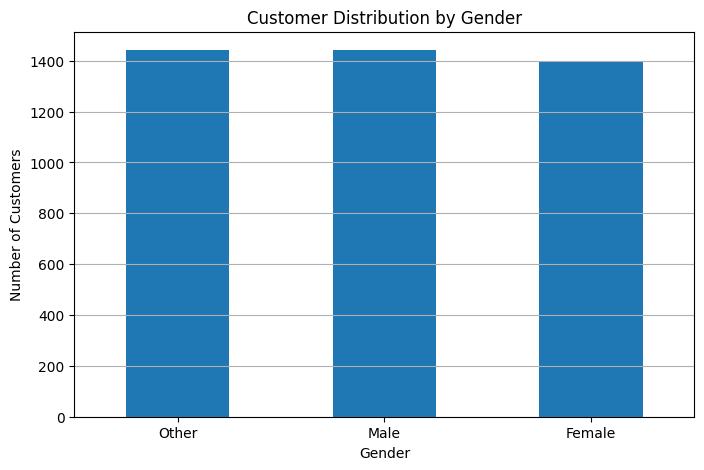

In [ ]:
gender_counts = df['gender_clean'].value_counts()

plt.figure(figsize=(8, 5))
gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

**Observation**:
The gender distribution shows that Other and Male customers have the same representation, with 1,442 customers each, while Female customers account for 1,396 customers. There are 30 records with missing gender information. Overall, the three recorded gender categories have relatively similar representation in the dataset.

In [ ]:
top_products = (
    df.groupby('product_name')['quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

product_name
Rice (5kg)        1568.0
Jeans             1563.0
Tennis Racket     1524.0
Jacket            1522.0
Fiction Novel     1519.0
Cook Book         1494.0
Self-Help Book    1483.0
Tablet            1470.0
Desk               656.0
Laptop             655.0
Name: quantity, dtype: float64


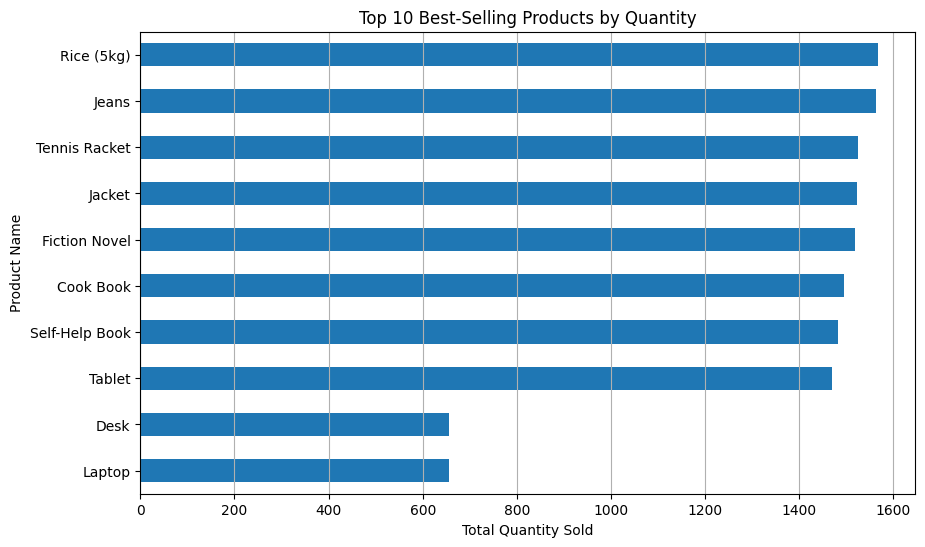

In [ ]:
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Name')
plt.grid(axis='x')
plt.show()

**Observation**:
The Top 10 best-selling products show that Rice (5kg) has the highest total quantity sold at 1,568 units, followed by Jeans with 1,563 units and Tennis Racket with 1,524 units. Desk and Laptop have the lowest quantities among the top 10 products, with 656 and 655 units respectively. The results indicate that the sales volume varies considerably across different products.

In [ ]:
category_revenue = (
    df.groupby('product_category')['sales_amount']
      .sum()
      .sort_values(ascending=False)
)

print(category_revenue)


product_category
Electronics    1.571703e+08
Furniture      5.713040e+07
Sports         3.209245e+07
Clothing       1.167328e+07
Beauty         3.967541e+06
Books          3.824242e+06
Groceries      1.036782e+06
Name: sales_amount, dtype: float64


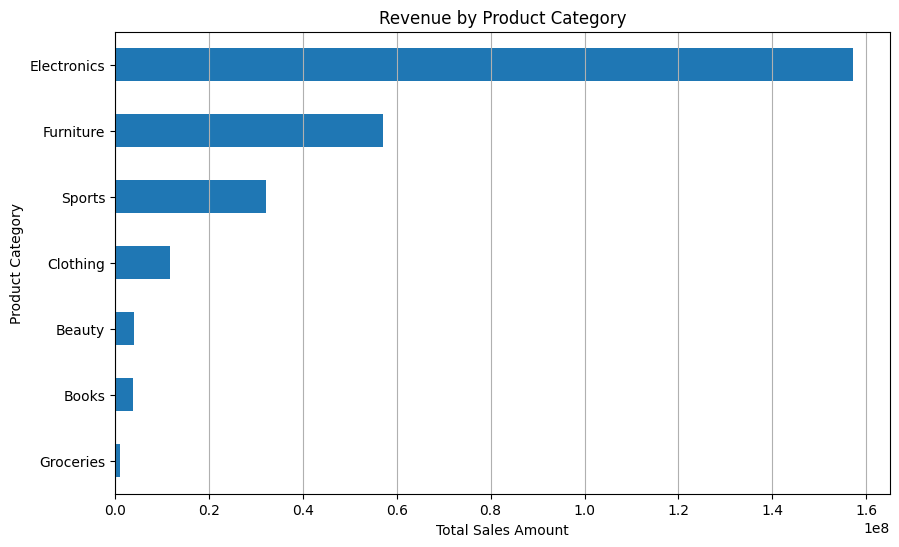

In [ ]:
plt.figure(figsize=(10, 6))
category_revenue.sort_values().plot(kind='barh')

plt.title('Revenue by Product Category')
plt.xlabel('Total Sales Amount')
plt.ylabel('Product Category')
plt.grid(axis='x')
plt.show()

**Observation**:
The revenue analysis shows that Electronics generates the highest revenue, with approximately 157.17 million, followed by Furniture at approximately 57.13 million and Sports at approximately 32.09 million. Groceries generates the lowest revenue at approximately 1.04 million. The results show a substantial difference in revenue contribution across product categories.

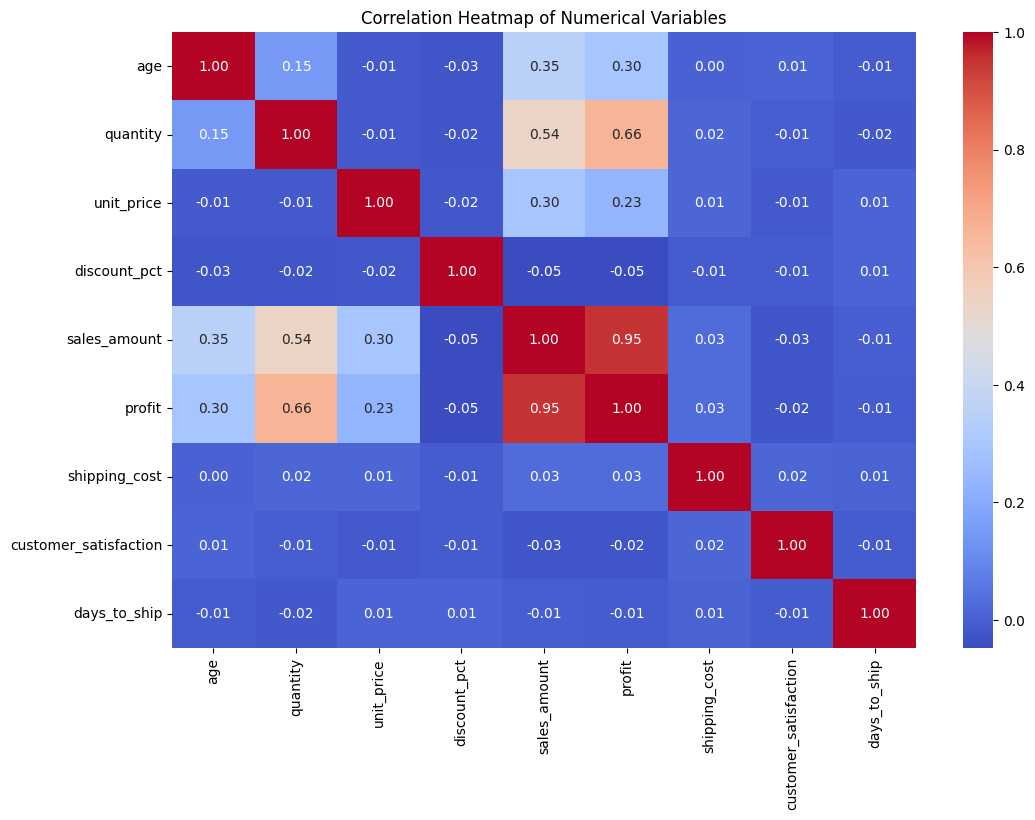

In [ ]:
numerical_data = df[
    ['age', 'quantity', 'unit_price', 'discount_pct',
     'sales_amount', 'profit', 'shipping_cost',
     'customer_satisfaction', 'days_to_ship']
]

correlation = numerical_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

**Observation:**

The heatmap shows the correlation between numerical variables in the dataset.

Sales amount and profit have a very strong positive correlation (0.95), indicating that higher sales are generally associated with higher profit.

Quantity and profit show a moderately strong positive correlation (0.66).

Quantity and sales amount also have a moderate positive correlation (0.54).

Age and sales amount have a moderate positive correlation (0.35), while age and profit have a correlation of 0.30.

Discount percentage has a very weak negative correlation with sales amount and profit (-0.05), suggesting little linear relationship.

Shipping cost, customer satisfaction, and days to ship have correlations close to zero with most variables, indicating very weak or negligible relationships.

Overall, sales amount, profit, and quantity are the most strongly related variables in the dataset.

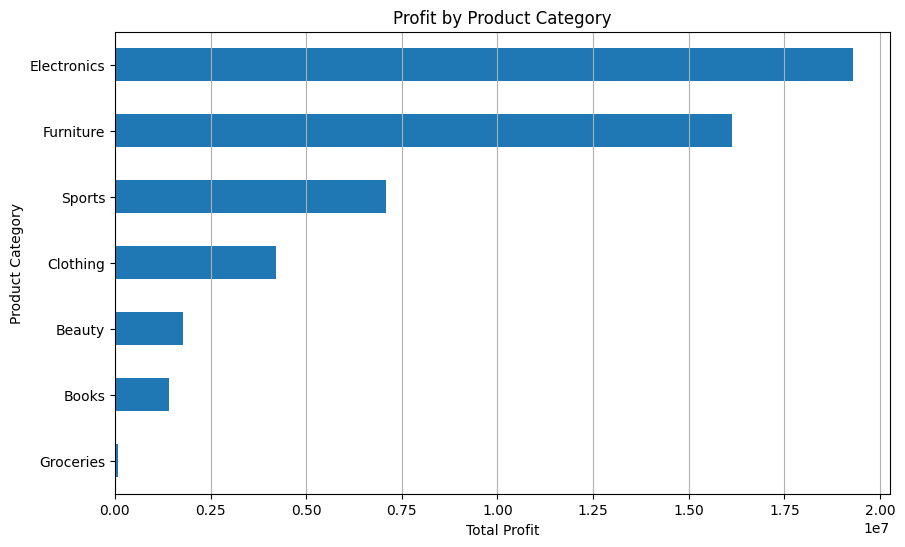

In [ ]:
category_profit = (
    df.groupby('product_category')['profit']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
category_profit.sort_values().plot(kind='barh')

plt.title('Profit by Product Category')
plt.xlabel('Total Profit')
plt.ylabel('Product Category')
plt.grid(axis='x')
plt.show()

**Observation:**
The bar chart shows the total profit generated by each product category. Electronics generates the highest total profit, followed by Furniture, while Sports ranks third. Clothing contributes a moderate amount of profit, whereas Beauty and Books contribute relatively lower profits. Groceries has the lowest total profit among all categories. Overall, Electronics and Furniture are the most profitable categories, while Groceries contributes the least.

## Conclusion

The exploratory data analysis provided useful insights into sales performance, customer demographics, product demand, and profitability. Sales showed considerable variation across months and quarters. Customers in the 26–35 age group formed the largest customer segment, while the gender distribution was relatively similar across the three recorded categories.

Rice (5kg) was the best-selling product by quantity, while Electronics generated the highest revenue and profit among product categories. The correlation analysis also showed strong relationships between sales amount, profit, and quantity.

## Actionable Business Recommendations

1. **Focus on Electronics:** Since Electronics generates the highest revenue and profit, the business should maintain sufficient inventory and prioritize marketing campaigns for high-performing electronic products.

2. **Promote Best-Selling Products:** Products such as Rice (5kg), Jeans, and Tennis Racket have high sales volumes. The business can use targeted promotions and bundle offers to maintain their strong demand.

3. **Improve Low-Performing Categories:** Groceries has the lowest revenue and profit contribution. The business should review pricing, product selection, and promotional strategies in this category.

4. **Target Key Customer Segments:** Since customers aged 26–35 form the largest age group, marketing campaigns can be tailored toward their preferences and purchasing behavior.

5. **Monitor Sales Fluctuations:** The large variations in monthly and quarterly sales suggest that the business should monitor periods of unusually high or low sales and plan inventory and promotions accordingly.